In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from openpiv import filters, pyprocess, validation
import matplotlib.pyplot as plt
from pathlib import Path

# --- PARAMETRI ---
INPUT_DIR = Path("F:\\Luca_Data\\20260925_test_microscope_and_camera\\fluoromax_0.25_1000fps_1uls")
OUTPUT_DIR = Path("results/piv")
PATTERN = "*.tif"  # Cambia l'estensione se le immagini non sono .tif

# Parametri di analisi
FIRST_FRAME = 0
FINAL_FRAME = 30
FRAME_STEP = 3



# Parametri PIV
WINDOW_SIZE = 32
OVERLAP = 16
SEARCH_AREA_SIZE = 64
DT_SECONDS = (1/1000)*FRAME_STEP       # 1000 fps (quindi 1 millisecondo tra i frame)
S2N_THRESHOLD = 1.3        # Soglia rapporto segnale/rumore

# Parametri di ritaglio (Crop)
# Ritaglia l'immagine per alleggerire l'analisi. Regola questi valori in base alla tua ROI.
CROP_Y_MIN = 100
CROP_Y_MAX = 800
CROP_X_MIN = 100
CROP_X_MAX = 900


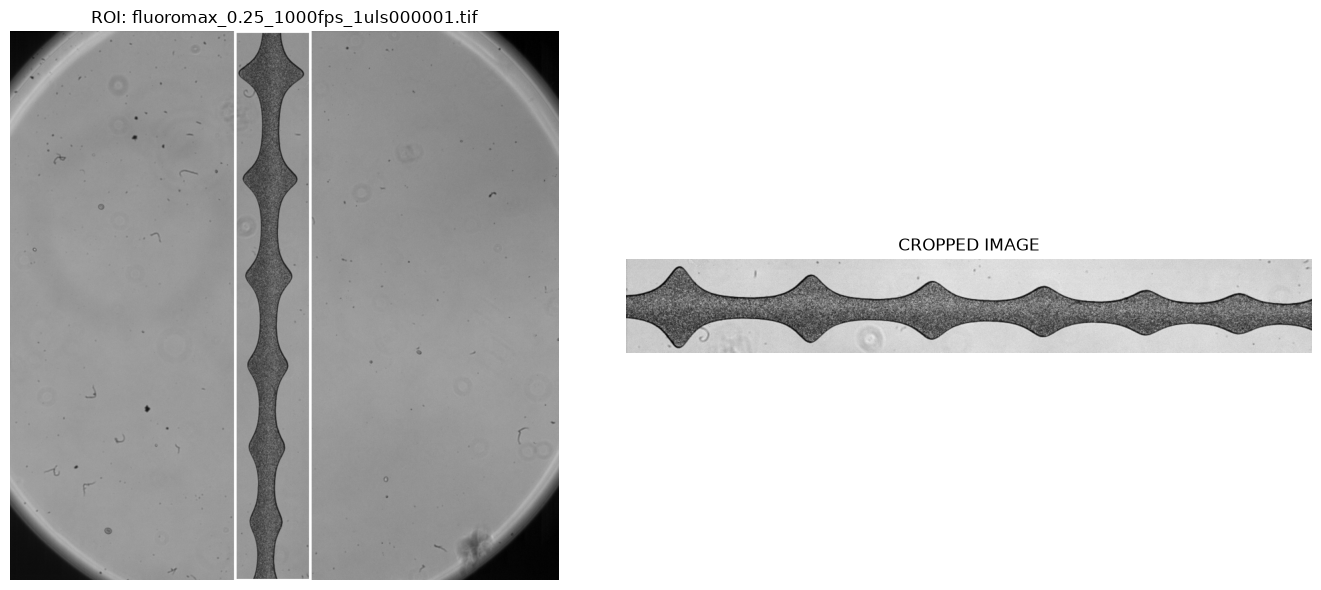

In [23]:
# Parametri di ritaglio (Crop)
# Ritaglia l'immagine per alleggerire l'analisi. Regola questi valori in base alla tua ROI.
CROP_Y_MIN = 0
CROP_Y_MAX = 1024
CROP_X_MIN = 420
CROP_X_MAX = 560

frames = sorted(INPUT_DIR.glob(PATTERN))

if not frames:
    raise FileNotFoundError(f"Nessuna immagine trovata in {INPUT_DIR} con pattern {PATTERN}")

# Legge l'immagine in scala di grigi.
image = cv2.imread(str(frames[0]), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError(f"Impossibile leggere l'immagine: {frames[0]}")

# Estrae la regione di interesse.
cropped = image[CROP_Y_MIN:CROP_Y_MAX, CROP_X_MIN:CROP_X_MAX]
cropped = cv2.rotate(cropped, cv2.ROTATE_90_COUNTERCLOCKWISE)  # Ruota di 90 gradi in senso antiorario

# Crea una copia per disegnare il rettangolo senza modificare l'immagine originale.
image_with_rectangle = image.copy()
cv2.rectangle(
    image_with_rectangle,
    (CROP_X_MIN, CROP_Y_MIN),  # Angolo in alto a sinistra: (x, y)
    (CROP_X_MAX, CROP_Y_MAX),  # Angolo in basso a destra: (x, y)
    color=255,                 # Bianco, dato che l'immagine è in scala di grigi
    thickness=3,
)



# Visualizza l'immagine originale con il rettangolo e, a fianco, il ritaglio.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image_with_rectangle, cmap="gray")
axes[0].set_title(f"ROI: {frames[0].name}")
axes[0].axis("off")

axes[1].imshow(cropped, cmap="gray")
axes[1].set_title("CROPPED IMAGE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Crea la cartella dei risultati se non esiste.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def read_gray_and_crop(path):
    """Legge un'immagine in scala di grigi e ritaglia la ROI."""

    # Carica l'immagine in scala di grigi.
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    # Se OpenCV non riesce a leggere il file, interrompe l'analisi
    # indicando il percorso problematico.
    if image is None:
        raise ValueError(f"Impossibile leggere l'immagine: {path}")

    # Seleziona la regione compresa tra i limiti impostati.
    # Le coordinate di ritaglio usano la forma [righe, colonne]
    cropped = image[CROP_Y_MIN:CROP_Y_MAX, CROP_X_MIN:CROP_X_MAX]

    return cropped


def analyze_pair(path_a, path_b):
    """Calcola il campo di spostamento tra due immagini consecutive."""

    # Legge e ritaglia i due frame.
    frame_a = read_gray_and_crop(path_a)
    frame_b = read_gray_and_crop(path_b)

    # Controlla che le immagini abbiano le stesse dimensioni.
    if frame_a.shape != frame_b.shape:
        raise ValueError(
            f"I frame hanno dimensioni diverse: "
            f"{frame_a.shape} e {frame_b.shape}"
        )

    # Stima gli spostamenti tra i due frame.
    # u e v sono le componenti dello spostamento; s2n è il rapporto
    # segnale-rumore usato per valutare l'affidabilità dei vettori.
    u, v, s2n = pyprocess.extended_search_area_piv(
        frame_a,
        frame_b,
        window_size=WINDOW_SIZE,
        overlap=OVERLAP,
        search_area_size=SEARCH_AREA_SIZE,
        dt=DT_SECONDS,
        sig2noise_method="peak2peak",
    )

    # Crea la maschera dei vettori non validi usando il rapporto segnale-rumore.
    # Nella tua versione di OpenPIV la funzione prende s2n e la soglia,
    # non u e v.
    invalid = validation.sig2noise_val(
        s2n,
        threshold=S2N_THRESHOLD,
    )

    # Sostituisce i vettori non validi con una media locale dei vettori vicini.
    u, v = filters.replace_outliers(
        u,
        v,
        invalid,
        method="localmean",
        max_iter=3,
        kernel_size=3,
    )

    # Calcola le coordinate dei vettori rispetto all'immagine ritagliata.
    x, y = pyprocess.get_coordinates(
        image_size=frame_a.shape,
        search_area_size=SEARCH_AREA_SIZE,
        overlap=OVERLAP,
    )

    # Restituisce anche invalid, che indica quali vettori erano stati
    # identificati come non validi prima della sostituzione.
    return x, y, u, v, s2n, invalid


def main():
    # Cerca i file nella cartella di input e li ordina per nome.
    # L'ordinamento determina l'ordine temporale dei frame.
    frames = sorted(INPUT_DIR.glob(PATTERN))

    # L'analisi richiede almeno due immagini per formare una coppia.
    if len(frames) < 2:
        raise RuntimeError(
            f"Servono almeno due immagini in {INPUT_DIR} con estensione {PATTERN}"
        )

    print(f"Trovati {len(frames)} frame. Inizio l'analisi...")


# Analizza la coppia e riceve il campo di spostamento e i dati associati.  
for output_index, i in enumerate(     # Crea coppie di frame consecutivi: 0-1, 1-2, 2-3 e così via.
        range(FIRST_FRAME, FINAL_FRAME - FRAME_STEP + 1, FRAME_STEP)
    ):
        path_a = frames[i]
        path_b = frames[i + FRAME_STEP]

        x, y, u, v, s2n, invalid = analyze_pair(path_a, path_b)
    # Crea coppie di frame consecutivi: 0-1, 1-2, 2-3 e così via.
    for index, (path_a, path_b) in enumerate(zip(frames, frames[1:])):
        # Analizza la coppia e riceve il campo di spostamento e i dati associati.
        x, y, u, v, s2n, invalid = analyze_pair(path_a, path_b)

        # Organizza i risultati in una tabella.
        # ravel() appiattisce le matrici in vettori monodimensionali,
        # così ogni riga rappresenta un punto del campo PIV.
        result = pd.DataFrame({
            "x_px": x.ravel(),                    # Coordinata x in pixel
            "y_px": y.ravel(),                    # Coordinata y in pixel
            "u_px_s": u.ravel(),                  # Componente orizzontale della velocità
            "v_px_s": v.ravel(),                  # Componente verticale della velocità
            "signal_to_noise": s2n.ravel(),       # Rapporto segnale-rumore
            "invalid": invalid.ravel(),           # Indicatore di vettore non valido
        })

        # Costruisce il percorso del CSV; il numero è formattato
        # con quattro cifre, ad esempio piv_0000.csv.
        output_path = OUTPUT_DIR / f"piv_{index:04d}.csv"

        # Salva la tabella senza aggiungere l'indice di pandas.
        result.to_csv(output_path, index=False)

        # Stampa l'avanzamento ogni 10 coppie per non riempire troppo l'output.
        if index % 10 == 0:
            print(
                f"Analizzato e salvato: frame {index}/{len(frames)-1} "
                f"-> {output_path.name}"
            )

    print("\nAnalisi completata con successo!")


# Avvia main() solo quando il file viene eseguito direttamente,
# non quando viene importato come modulo.
if __name__ == "__main__":
    main()

Trovati 2726 frame. Inizio l'analisi...
Analizzato e salvato: frame 0/2725 -> piv_0000.csv
Analizzato e salvato: frame 10/2725 -> piv_0010.csv
Analizzato e salvato: frame 20/2725 -> piv_0020.csv
Analizzato e salvato: frame 30/2725 -> piv_0030.csv
Analizzato e salvato: frame 40/2725 -> piv_0040.csv
Analizzato e salvato: frame 50/2725 -> piv_0050.csv
Analizzato e salvato: frame 60/2725 -> piv_0060.csv
Analizzato e salvato: frame 70/2725 -> piv_0070.csv
Analizzato e salvato: frame 80/2725 -> piv_0080.csv
Analizzato e salvato: frame 90/2725 -> piv_0090.csv
Analizzato e salvato: frame 100/2725 -> piv_0100.csv
Analizzato e salvato: frame 110/2725 -> piv_0110.csv
Analizzato e salvato: frame 120/2725 -> piv_0120.csv
Analizzato e salvato: frame 130/2725 -> piv_0130.csv
Analizzato e salvato: frame 140/2725 -> piv_0140.csv
Analizzato e salvato: frame 150/2725 -> piv_0150.csv
Analizzato e salvato: frame 160/2725 -> piv_0160.csv
Analizzato e salvato: frame 170/2725 -> piv_0170.csv
Analizzato e salv

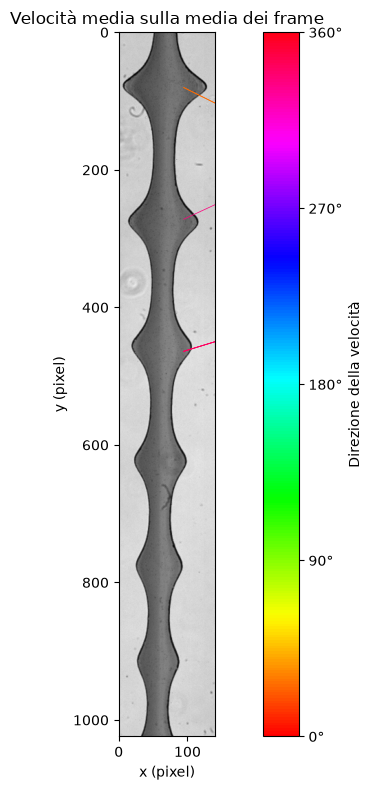

In [ ]:
# i vettori devono essere disegnati sull immagine media di tutti i frame posizionata in orizzontale (ruotata di 90 gradi conterclockwise), su un reticolo quadrato uno ogni 150 pixel con una scala di colori che dipende dalla direzione della velocita e una lunghezza del vettore proporzionale al ;odulo delle velocita, accanto al grafico deve essere ;ostrata la colormap dei vettori associata all angolo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.spatial import cKDTree

# Calcola l'immagine media usando tutti i frame della cartella.
image_paths = sorted(INPUT_DIR.glob(PATTERN))
if not image_paths:
    raise FileNotFoundError(f"Nessuna immagine trovata in {INPUT_DIR}")

image_sum = None

for path in image_paths:
    frame = read_gray_and_crop(path).astype(np.float64)

    if image_sum is None:
        image_sum = np.zeros_like(frame)
    elif frame.shape != image_sum.shape:
        raise ValueError(f"Dimensioni non uniformi per il frame: {path}")

    image_sum += frame

mean_image = image_sum / len(image_paths)

# Legge i CSV prodotti dall'analisi.
csv_files = sorted(OUTPUT_DIR.glob("piv_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Nessun CSV piv_*.csv trovato in {OUTPUT_DIR}")

data = pd.concat(
    [pd.read_csv(path) for path in csv_files],
    ignore_index=True,
)

# Esclude i vettori segnalati come non validi.
invalid = data["invalid"].astype(str).str.strip().str.lower().isin(["true", "1"])
data = data.loc[~invalid].copy()

if data.empty:
    raise ValueError("Non ci sono vettori validi da visualizzare.")

# Calcola le componenti medie della velocità in ogni posizione.
mean_velocity = (
    data.groupby(["x_px", "y_px"], as_index=False)
    .agg(u=("u_px_s", "mean"), v=("v_px_s", "mean"))
)

# Crea una griglia di punti distanti 150 pixel e, per ciascuno,
# seleziona il punto PIV disponibile più vicino.
spacing = 150
grid_x, grid_y = np.meshgrid(
    np.arange(0, mean_image.shape[1], spacing),
    np.arange(0, mean_image.shape[0], spacing),
)
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

piv_points = mean_velocity[["x_px", "y_px"]].to_numpy()
tree = cKDTree(piv_points)
_, nearest_indices = tree.query(grid_points)

sampled = mean_velocity.iloc[nearest_indices]

x = sampled["x_px"].to_numpy()
y = sampled["y_px"].to_numpy()
u = sampled["u"].to_numpy()
v = sampled["v"].to_numpy()

# L'angolo determina il colore; il modulo determina la lunghezza.
angle = np.mod(np.arctan2(v, u), 2 * np.pi)

# Regola questo fattore per rendere i vettori più o meno lunghi sul grafico.
length_scale = 10

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(mean_image, cmap="gray", origin="upper")

vectors = ax.quiver(
    x, y,
    u * length_scale,
    v * length_scale,
    angle,
    angles="xy",
    scale_units="xy",
    scale=1,
    cmap="hsv",
    norm=Normalize(vmin=0, vmax=2 * np.pi),
)

# La barra colori associa i colori all'angolo della velocità.
colorbar = fig.colorbar(vectors, ax=ax, ticks=[0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
colorbar.ax.set_yticklabels(["0°", "90°", "180°", "270°", "360°"])
colorbar.set_label("Direzione della velocità")

ax.set_title("Velocità media sulla media dei frame")
ax.set_xlabel("x (pixel)")
ax.set_ylabel("y (pixel)")
ax.set_xlim(0, mean_image.shape[1])
ax.set_ylim(mean_image.shape[0], 0)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()
